In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [2]:
directory_path = '../Data/Domain Data/Original data (as is)/PhishLab Ukraine-related-Domains'

domain_frequency_per_day = {}
# domain_with_date = {}

for filename in os.listdir(directory_path):
    filepath = os.path.join(directory_path, filename)
    # print(filename[16:26])
    if os.path.isfile(filepath):
        with open(filepath, 'r') as file:
            content = file.read()
            # Process the content of the file
            # print(content)
            flag = 'Y).'
            # print(content.index(flag))
            # print((content[322+len(flag)+1:].split('\n')))
            # for i in content[322+len(flag)+1:].split('\n'):
            #     domain_with_date[i] = filename[16:26]

            # print(filename[16:26])
            # break
            domain_frequency_per_day[filename[16:26]] = len(content[322+len(flag)+1:].split('\n'))


# domain_with_date
    

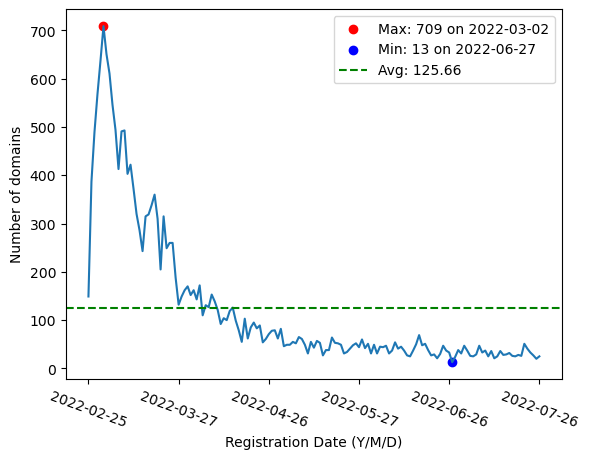

In [3]:
import matplotlib.pyplot as plt

# Data for plotting
dates = list(domain_frequency_per_day.keys())
frequencies = list(domain_frequency_per_day.values())

# Plot the data
plt.plot(dates, frequencies)

# Label the axes
plt.xlabel('Registration Date (Y/M/D)')
plt.ylabel('Number of domains')

# Set x-ticks at intervals of 30
xtick_positions = list(range(0, len(dates), 30))
xtick_labels = [dates[i] for i in xtick_positions]
plt.xticks(xtick_positions, xtick_labels, rotation=-20)

# Highlight the max point
max_value = max(frequencies)
max_idx = frequencies.index(max_value)
plt.scatter(dates[max_idx], max_value, color='red', label=f'Max: {max_value} on {dates[max_idx]}')

# Highlight the min point
min_value = min(frequencies)
min_idx = frequencies.index(min_value)
plt.scatter(dates[min_idx], min_value, color='blue', label=f'Min: {min_value} on {dates[min_idx]}')

# Plot average line
avg = sum(frequencies) / len(frequencies)
plt.axhline(y=avg, color='green', linestyle='--', label=f'Avg: {round(avg, 2)}')

# Title
# plt.title('Per-day Domain registration count from Feb 25 - Jul 26, 2022')

# Show legend
plt.legend()

# Show the plot
plt.show()


In [4]:
df = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 54 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [5]:
df['Majority Voting Label']

0       0
1       0
2       0
3       0
4       2
       ..
2113    0
2114    0
2115    0
2116    0
2117    0
Name: Majority Voting Label, Length: 2118, dtype: int64

In [6]:
df.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score,VT Malicious,VT Suspicious,VT Harmless,VT NoData Available,Domain Creation Date
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,False,False,False,False,0,0,0,1,1,2022-03-10
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,False,False,True,False,55,0,0,1,1,2022-06-06
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,False,False,False,False,0,1,0,0,1,2022-04-03
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,False,False,True,False,55,0,0,1,1,2022-06-01
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,False,True,True,False,91,0,0,1,1,2022-03-22


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_domain_creation_by_label(df):
    """
    Plots the creation date of domains, stacked on the y-axis,
    with different colors representing labels.

    Args:
        df (pd.DataFrame): DataFrame with 'Domain Name', 'Created On', and 'Majority Voting Label' columns.
    """

    # Ensure 'Created On' is in datetime format
    df['Created On'] = pd.to_datetime(df['Domain Creation Date'])

    # Get unique labels for coloring
    unique_labels = df['Majority Voting Label'].unique()
    colors = plt.cm.get_cmap('viridis', len(unique_labels)) # You can choose a different colormap

    fig, ax = plt.subplots(figsize=(10, 6))

    y_offset = 0
    for label_value, color in zip(unique_labels, colors.colors):
        subset = df[df['Majority Voting Label'] == label_value]
        ax.scatter(subset['Created On'], [y_offset] * len(subset), color=color, label=f'Majority Voting Label {label_value}', s=20)
        y_offset += 0.8 # Adjust this value to control the stacking distance

    # Format the x-axis to display dates nicely
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_yticks([]) # Remove y-axis ticks as the position is just for stacking
    ax.set_ylabel('Domains (Stacked by Majority Voting Label)')
    ax.set_xlabel('Creation Date')
    ax.set_title('Domain Creation Dates Stacked by Majority Voting Label')
    # ax.legend(title='Majority Voting Label', fontsize=10)
    plt.tight_layout()
    plt.show()


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

def plot_domain_creation_by_label(df):
    """
    Plots the distribution of domain creation dates using histograms, grouped by label.

    Args:
        df (pd.DataFrame): DataFrame with 'Domain Name', 'Domain Creation Date', and 'Majority Voting Label' columns.
    """

    # Ensure 'Domain Creation Date' is in datetime format
    df['Domain Creation Date'] = pd.to_datetime(df['Domain Creation Date'])

    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x='Domain Creation Date', hue='Majority Voting Label', multiple='stack', kde=False)
    # If you prefer density plots instead of histograms, uncomment the line below and comment out the histplot line:
    # sns.kdeplot(data=df, x='Domain Creation Date', hue='Majority Voting Label', fill=True, alpha=0.3)

    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Creation Date')
    plt.ylabel('Frequency') # Or 'Density' if using kdeplot
    plt.title('Distribution of Domain Creation Dates by Majority Voting Label (Histogram)')
    plt.legend(title='Majority Voting Label')
    plt.tight_layout()
    plt.show()

C:\Users\mmia43\AppData\Local\Temp\ipykernel_31984\2511479372.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels)) # You can choose a different colormap


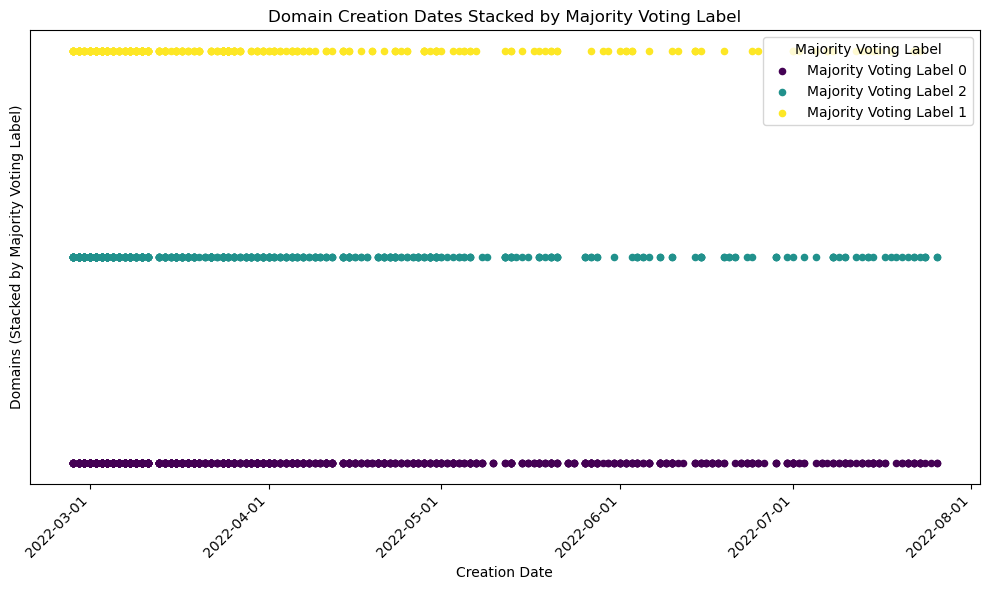

In [10]:
plot_domain_creation_by_label(df)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


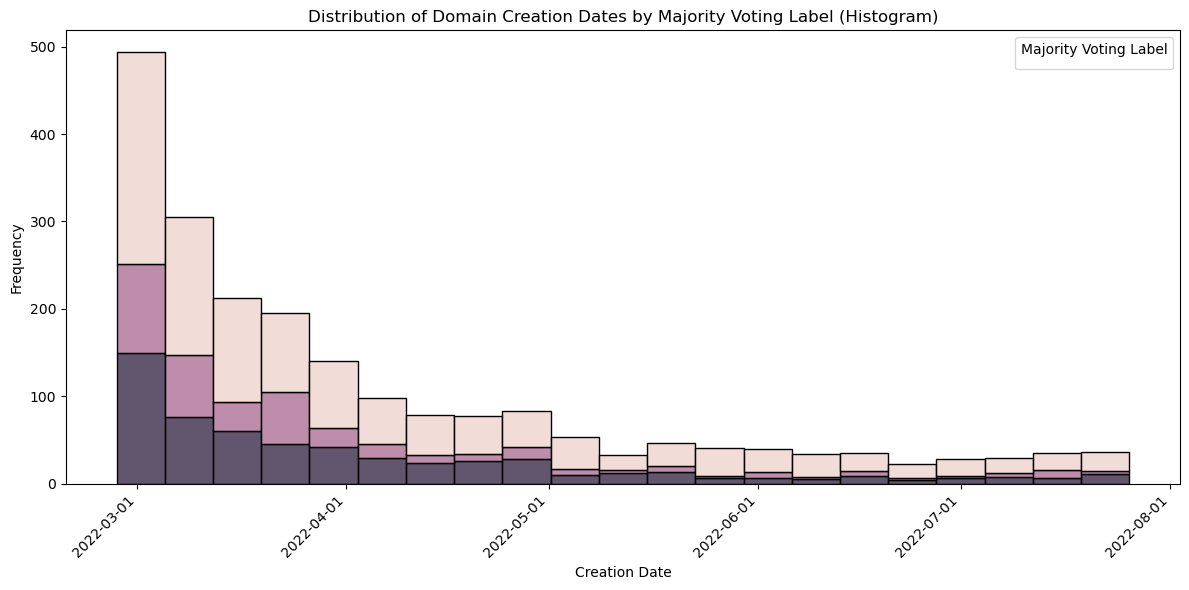

In [15]:
plot_domain_creation_by_label(df)

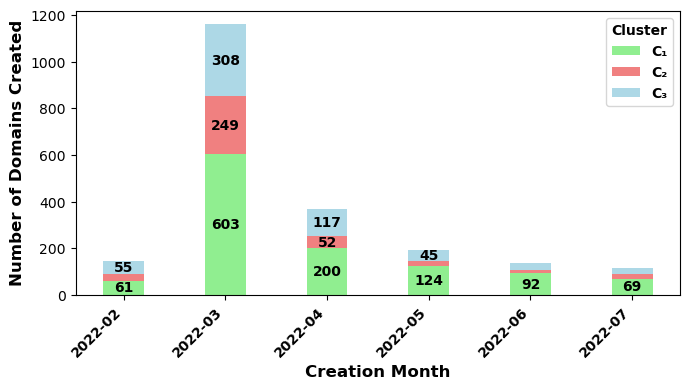

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_domain_creation_monthly_stacked_bar_with_counts(df):
    """
    Plots a stacked bar chart of domain creation counts by month, grouped by cluster label,
    with adjusted bar width, spacing, plot height, bold text, and conditional text display.

    Args:
        df (pd.DataFrame): DataFrame with 'Domain Name', 'Domain Creation Date', and 'Majority Voting Label' columns.
    """
    # Ensure 'Domain Creation Date' is in datetime format
    df['Domain Creation Date'] = pd.to_datetime(df['Domain Creation Date'])

    # Extract month from 'Domain Creation Date'
    df['Creation Month'] = df['Domain Creation Date'].dt.to_period('M')

    # Group by month and label, then count domains
    monthly_counts = df.groupby(['Creation Month', 'Majority Voting Label']).size().unstack(fill_value=0)

    # Sort the index (months)
    monthly_counts = monthly_counts.sort_index()

    # Define colors for the bars
    colors = ['lightgreen', 'lightcoral', 'lightblue']
    labels = ['C₁', 'C₂', 'C₃']  # Corresponding labels for the legend

    # Set the width of the bars
    bar_width = 0.4  # Default is 0.8; try a smaller value

    # Calculate the positions for the bars
    num_months = len(monthly_counts.index)
    x = range(num_months)

    # Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(7, 4))  # Reduced y-dimension (height)

    bottom = [0] * num_months
    for label_idx, label_col in enumerate(monthly_counts.columns):
        counts = monthly_counts[label_col].values
        bars = ax.bar(x, counts, bar_width, bottom=bottom, color=colors[label_idx], label=labels[label_idx])
        bottom = [b + c for b, c in zip(bottom, counts)]
        for rect in bars:
            height = rect.get_height()
            if height > 30:  # Only add text if height is above this threshold
                y_pos = rect.get_y() + height / 2
                ax.text(rect.get_x() + rect.get_width() / 2, y_pos, f'{int(height)}',
                        ha='center', va='center', color='black', fontsize=10, fontweight='bold')

    # Format x-axis (months)
    ax.set_xlabel('Creation Month', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Domains Created', fontweight='bold', fontsize=12)
    # ax.set_title('Stacked Bar Chart of Monthly Domain Creation Counts by Cluster Label')

    # Set x-axis tick positions and labels
    ax.set_xticks(x)
    ax.set_xticklabels([month.strftime('%Y-%m') for month in monthly_counts.index], rotation=45, ha='right', fontweight='bold', fontsize=10)

    # Add a legend with bold text
    legend = ax.legend(title='Cluster', fontsize=10)
    if legend:
        for text in legend.get_texts():
            text.set_fontweight('bold')
        if legend.get_title():
            legend.get_title().set_fontweight('bold')

    plt.tight_layout()
    plt.show()

# Assuming you have your DataFrame named 'df'
plot_domain_creation_monthly_stacked_bar_with_counts(df)

In [44]:


print(df['Domain Creation Date'].min())
print(df['Domain Creation Date'].max())

2022-02-26 00:00:00
2022-07-26 00:00:00
